In [83]:
# Importing of Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:

# Import all datasets

customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

print(customers.shape)
print(orders.shape)
print(order_items.shape)
print(payments.shape)
print(reviews.shape)
print(products.shape)
print(sellers.shape)
print(geolocation.shape)
print(category_translation.shape)

(99441, 5)
(99441, 8)
(112650, 7)
(103886, 5)
(99224, 7)
(32951, 9)
(3095, 4)
(1000163, 5)
(71, 2)


In [85]:
print(orders.isnull().sum())
print(orders.duplicated().sum())
print(orders.dtypes)

print(reviews.isnull().sum())
print(reviews.duplicated().sum())

review_order_counts = reviews.groupby('order_id').size()
duplicate_review_orders = review_order_counts[review_order_counts > 1]
print(duplicate_review_orders.shape)

print(products.isnull().sum())
print(geolocation.duplicated().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
0
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
0
(547,)
product_id                      0
product_category_name         610
product_name_lenght       

In [86]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])
reviews = reviews.sort_values('review_answer_timestamp', ascending=False)
reviews = reviews.drop_duplicates(subset='order_id', keep='first')

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

geolocation = geolocation.drop_duplicates()

products['product_category_name'] = products['product_category_name'].fillna('unknown')

print(orders.dtypes)
print(reviews.shape)
print(geolocation.shape)
print(products.isnull().sum())

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
(98673, 7)
(738332, 5)
product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


#### Merging of DataFrames ####

In [87]:
order_items_full = order_items.merge(products, on='product_id', how='left')
order_items_full = order_items_full.merge(sellers, on='seller_id', how='left')

payments_sum = payments.groupby('order_id')['payment_value'].sum()
payments_max_installments = payments.groupby('order_id')['payment_installments'].max()
payments_type = payments.groupby('order_id')['payment_type'].first()

payments_agg = pd.DataFrame({
    'total_payment_value': payments_sum,
    'payment_installments_max': payments_max_installments,
    'payment_type': payments_type
})
payments_agg = payments_agg.reset_index()

orders_full = orders.merge(customers, on='customer_id', how='left')
orders_full = orders_full.merge(payments_agg, on='order_id', how='left')

reviews_slim = reviews[['order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']]
orders_full = orders_full.merge(reviews_slim, on='order_id', how='left')

master_df = order_items_full.merge(orders_full, on='order_id', how='left')

print(master_df.shape)
print(master_df.columns.tolist())

(112650, 35)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment_value', 'payment_installments_max', 'payment_type', 'review_score', 'review_creation_date', 'review_answer_timestamp']


#### Sales & revenue Analysis ####

In [88]:
#Checking if revenue = price before freight

master_df['item_revenue'] = master_df['price']
master_df[['price', 'item_revenue']].head()

,price,item_revenue
0,58.90,58.90
1,239.90,239.90
2,199.00,199.00
3,12.99,12.99
4,199.90,199.90


In [89]:
#Extract order month for a time-series trend

master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')
master_df[['order_purchase_timestamp', 'order_month']].head()

,order_purchase_timestamp,order_month
0,2017-09-13 08:59:02,2017-09
1,2017-04-26 10:53:06,2017-04
2,2018-01-14 14:33:31,2018-01
3,2018-08-08 10:00:35,2018-08
4,2017-02-04 13:57:51,2017-02


In [90]:
# Aggregate revenue by month
monthly_revenue = master_df.groupby('order_month')['item_revenue'].sum()
print(monthly_revenue)

order_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: item_revenue, dtype: float64


In [91]:
# Data last real date transaction

master_df['order_purchase_timestamp'].max()

Timestamp('2018-09-03 09:06:57')

In [92]:
# Dropping 2018-009 data

monthly_revenue_trimmed = monthly_revenue.drop('2018-09')

print(monthly_revenue_trimmed.tail())

order_month
2018-04    996647.75
2018-05    996517.68
2018-06    865124.31
2018-07    895507.22
2018-08    854686.33
Freq: M, Name: item_revenue, dtype: float64


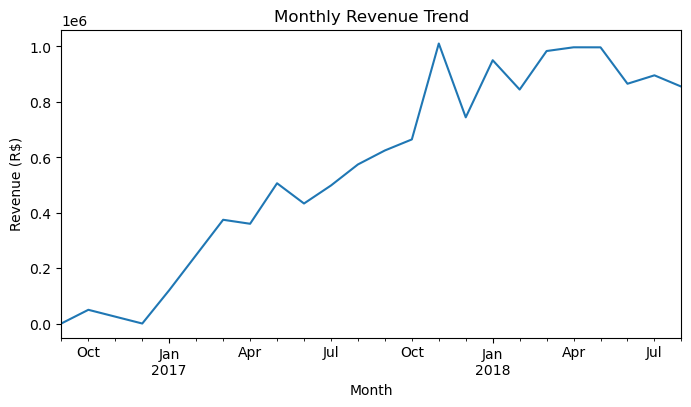

In [93]:
# Line Chart for Monthly revenue

monthly_revenue_trimmed.plot(kind='line', figsize=(8,4))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.show()

In [94]:
# Revenue by category

category_revenue = master_df.groupby('product_category_name')['item_revenue'].sum()
category_revenue_sorted = category_revenue.sort_values(ascending=False)
print(category_revenue_sorted.head(10))

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: item_revenue, dtype: float64


In [95]:
# Translating category name from Portuge to English

category_translation_dict = dict(zip(category_translation['product_category_name'], category_translation['product_category_name_english']))
master_df['product_category_name_english'] = master_df['product_category_name'].map(category_translation_dict)

master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('unknown')
print(master_df[['product_category_name', 'product_category_name_english']].head())

  product_category_name product_category_name_english
0            cool_stuff                    cool_stuff
1              pet_shop                      pet_shop
2      moveis_decoracao               furniture_decor
3            perfumaria                     perfumery
4    ferramentas_jardim                  garden_tools


In [96]:
# Re-running the command to be appearing in english

category_revenue = master_df.groupby('product_category_name_english')['item_revenue'].sum()
category_revenue_sorted = category_revenue.sort_values(ascending=False)
print(category_revenue_sorted.head(10))

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: item_revenue, dtype: float64


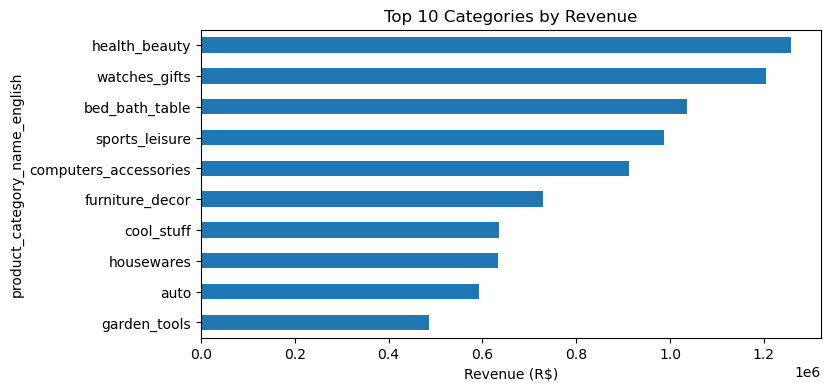

In [97]:
# Top 10 categories

top_10_categories = category_revenue_sorted.head(10)
top_10_categories.plot(kind='barh', figsize=(8,4))
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.gca().invert_yaxis()
plt.show()

In [98]:
# Revenue by state

state_revenue = master_df.groupby('customer_state')['item_revenue'].sum()
state_revenue_sorted = state_revenue.sort_values(ascending=False)

print(state_revenue_sorted.head(10))

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: item_revenue, dtype: float64


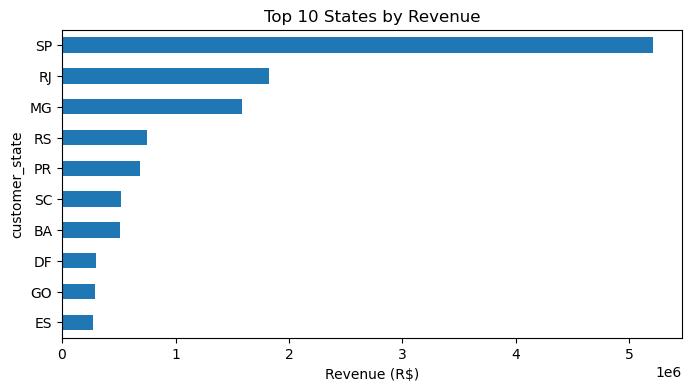

In [99]:
# Plotting revenue by state

top_10_states = state_revenue_sorted.head(10)
top_10_states.plot(kind='barh', figsize=(8,4))
plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue (R$)')
plt.gca().invert_yaxis()
plt.show()

In [122]:
customers_per_state = master_df.groupby('customer_state')['customer_unique_id'].nunique()
print(customers_per_state.sort_values(ascending=False).head(10))

customer_state
SP    39981
RJ    12303
MG    11178
RS     5249
PR     4840
SC     3513
BA     3257
DF     2062
ES     1956
GO     1942
Name: customer_unique_id, dtype: int64


In [124]:
revenue_per_customer = state_revenue / customers_per_state
revenue_per_customer_sorted = revenue_per_customer.sort_values(ascending=False)
print(revenue_per_customer_sorted.head(10))

customer_state
PB    223.387752
AC    207.570779
AL    201.290251
AP    201.108955
RO    196.343149
PA    189.563358
TO    182.432868
PI    180.694553
MT    179.213666
RN    176.295074
dtype: float64


In [126]:
print(customers_per_state[['PB', 'AC', 'AL', 'AP', 'RO']])

customer_state
PB    516
AC     77
AL    399
AP     67
RO    235
Name: customer_unique_id, dtype: int64


In [ ]:
# Why continue with revenue by customers per state even though SP clearly shows the highest in revenue?
# The revenue by states show how many people lives there,SP is the largest thus it is the top in revenue ranking,
# However to get a better insight is to divide the revenue by unique customers, in this way we are able to determine
# which customers from the state is most valuable

In [130]:
#Removing states that don't meet customer threshold

states_with_enough_customers = customers_per_state[customers_per_state >= 100]
revenue_per_customer_filtered = revenue_per_customer[states_with_enough_customers.index]
revenue_per_customer_filtered_sorted = revenue_per_customer_filtered.sort_values(ascending=False)
print(revenue_per_customer_filtered_sorted.head(10))

customer_state
PB    223.387752
AL    201.290251
RO    196.343149
PA    189.563358
TO    182.432868
PI    180.694553
MT    179.213666
RN    176.295074
SE    174.322041
CE    174.141540
dtype: float64


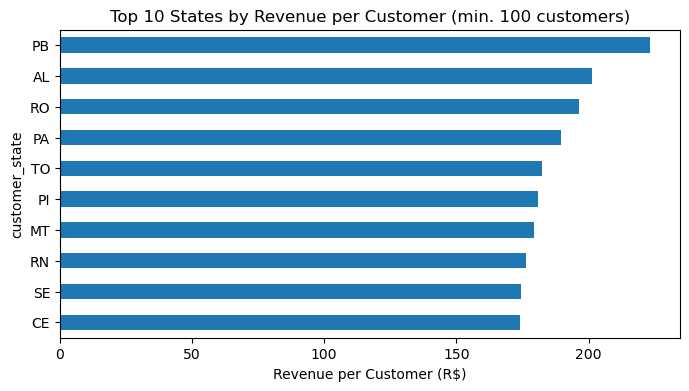

In [132]:
# Top 10 State Cutomers by Revenue

top_10_revenue_per_customer = revenue_per_customer_filtered_sorted.head(10)
top_10_revenue_per_customer.plot(kind='barh', figsize=(8,4))
plt.title('Top 10 States by Revenue per Customer (min. 100 customers)')
plt.xlabel('Revenue per Customer (R$)')
plt.gca().invert_yaxis()
plt.show()

#### Logistic & Delivery Performance ####

In [143]:
# Calculate delivery timings by Days

master_df['delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days
print(master_df['delivery_days'].describe())

count    110196.000000
mean         12.007723
std           9.451455
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64


In [145]:
# Checking for slowest deliveries

slowest_deliveries = master_df.sort_values('delivery_days', ascending=False)
print(slowest_deliveries[['order_id', 'delivery_days', 'order_status']].head(10))

                               order_id  delivery_days order_status
88935  ca07593549f1816d26a572e06dc1eab6          209.0    delivered
12000  1b3190b2dfa9d789e1f14c05b647a14a          208.0    delivered
29937  440d0d17af552815d15a9e41abe49359          195.0    delivered
6753   0f4519c5f1c541ddec9f21b3bddd533a          194.0    delivered
17603  285ab9426d6982034523a855f55a885e          194.0    delivered
20850  2fb597c2f772eca01b1f5c561bf6cc7b          194.0    delivered
31608  47b40429ed8cce3aee9199792275433f          191.0    delivered
20935  2fe324febf907e3ea3f2aa9650869fa5          189.0    delivered
19804  2d7561026d542c8dbd8f0daeadf67a43          188.0    delivered
29646  437222e3fd1b07396f1d9ba8c15fba59          187.0    delivered


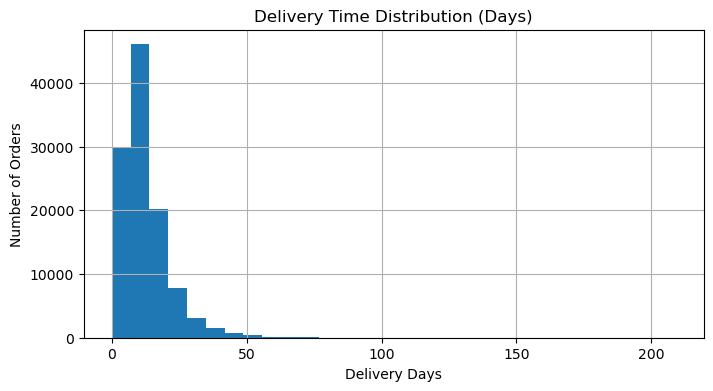

In [147]:
# Plotting Delivery time distribution

master_df['delivery_days'].hist(bins=30, figsize=(8,4))
plt.title('Delivery Time Distribution (Days)')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.show()

In [151]:
# Checking for late actual deliveries vs estimated

master_df['is_late'] = master_df['order_delivered_customer_date'] > master_df['order_estimated_delivery_date']
print(master_df['is_late'].value_counts())

is_late
False    103935
True       8715
Name: count, dtype: int64


In [155]:
# Segregating 'Late Delivey' & 'Never Delivered'
never_delivered = master_df['order_delivered_customer_date'].isnull().sum()
print(never_delivered)

2454


In [159]:
# Obtaining Delivery Status Category

def get_delivery_status(row):
    if pd.isnull(row['order_delivered_customer_date']):
        return 'never_delivered'
    elif row['order_delivered_customer_date'] > row['order_estimated_delivery_date']:
        return 'late'
    else:
        return 'on_time'

master_df['delivery_status'] = master_df.apply(get_delivery_status, axis=1)
print(master_df['delivery_status'].value_counts())

delivery_status
on_time            101481
late                 8715
never_delivered      2454
Name: count, dtype: int64


delivery_status
on_time            90.085220
late                7.736352
never_delivered     2.178429
Name: proportion, dtype: float64


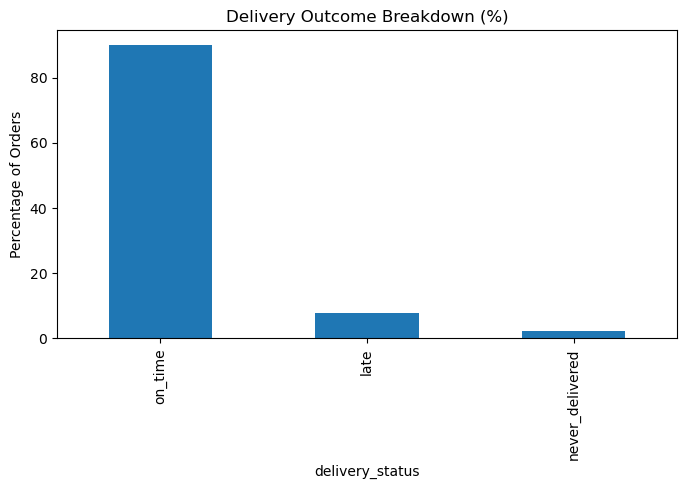

In [161]:
# Plotting Delivery Status in %

delivery_status_pct = master_df['delivery_status'].value_counts(normalize=True) * 100
print(delivery_status_pct)

delivery_status_pct.plot(kind='bar', figsize=(8,4))
plt.title('Delivery Outcome Breakdown (%)')
plt.ylabel('Percentage of Orders')
plt.show()

In [163]:
# Average Delivery Status Review Score

avg_review_by_status = master_df.groupby('delivery_status')['review_score'].mean()
print(avg_review_by_status)

delivery_status
late               2.547418
never_delivered    1.746473
on_time            4.211375
Name: review_score, dtype: float64


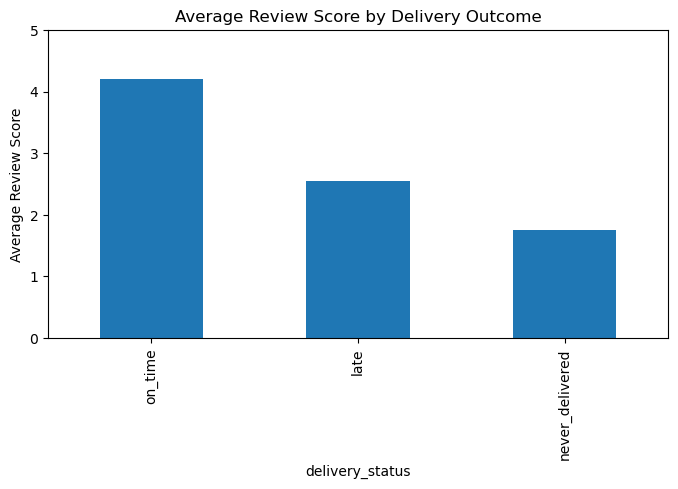

In [165]:
# Plotting Average delivey Score Review Status

avg_review_by_status_sorted = avg_review_by_status.sort_values(ascending=False)
avg_review_by_status_sorted.plot(kind='bar', figsize=(8,4))
plt.title('Average Review Score by Delivery Outcome')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.show()

#### Customer Segmentation (RFM) ####

In [170]:
# Obtaining snapshotdate

snapshot_date = master_df['order_purchase_timestamp'].max()
print(snapshot_date)

2018-09-03 09:06:57


In [174]:
# Calculate RFM

recency_df = master_df.groupby('customer_unique_id')['order_purchase_timestamp'].max()
recency_df = (snapshot_date - recency_df).dt.days

frequency_df = master_df.groupby('customer_unique_id')['order_id'].nunique()

monetary_df = master_df.groupby('customer_unique_id')['item_revenue'].sum()

print(recency_df.head())
print(frequency_df.head())
print(monetary_df.head())

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    115
0000b849f77a49e4a4ce2b2a4ca5be3f    118
0000f46a3911fa3c0805444483337064    541
0000f6ccb0745a6a4b88665a16c9f078    325
0004aac84e0df4da2b147fca70cf8255    292
Name: order_purchase_timestamp, dtype: int64
customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64
customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    129.90
0000b849f77a49e4a4ce2b2a4ca5be3f     18.90
0000f46a3911fa3c0805444483337064     69.00
0000f6ccb0745a6a4b88665a16c9f078     25.99
0004aac84e0df4da2b147fca70cf8255    180.00
Name: item_revenue, dtype: float64


In [176]:
# Combining RFM in one table

rfm_df = pd.DataFrame({
    'recency': recency_df,
    'frequency': frequency_df,
    'monetary': monetary_df
})

print(rfm_df.head())
print(rfm_df.describe())

                                  recency  frequency  monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      115          1    129.90
0000b849f77a49e4a4ce2b2a4ca5be3f      118          1     18.90
0000f46a3911fa3c0805444483337064      541          1     69.00
0000f6ccb0745a6a4b88665a16c9f078      325          1     25.99
0004aac84e0df4da2b147fca70cf8255      292          1    180.00
            recency     frequency      monetary
count  95420.000000  95420.000000  95420.000000
mean     242.600377      1.034018    142.440198
std      153.160320      0.211234    217.656355
min        0.000000      1.000000      0.850000
25%      118.000000      1.000000     47.900000
50%      223.000000      1.000000     89.900000
75%      352.000000      1.000000    155.000000
max      728.000000     16.000000  13440.000000


In [180]:
# Ranking them in 4 quartiles

rfm_df['r_score'] = pd.qcut(rfm_df['recency'], 4, labels=[4, 3, 2, 1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], 4, labels=[1, 2, 3, 4])

print(rfm_df.head())

                                  recency  frequency  monetary r_score  \
customer_unique_id                                                       
0000366f3b9a7992bf8c76cfdf3221e2      115          1    129.90       4   
0000b849f77a49e4a4ce2b2a4ca5be3f      118          1     18.90       4   
0000f46a3911fa3c0805444483337064      541          1     69.00       1   
0000f6ccb0745a6a4b88665a16c9f078      325          1     25.99       2   
0004aac84e0df4da2b147fca70cf8255      292          1    180.00       2   

                                 f_score m_score  
customer_unique_id                                
0000366f3b9a7992bf8c76cfdf3221e2       1       3  
0000b849f77a49e4a4ce2b2a4ca5be3f       1       1  
0000f46a3911fa3c0805444483337064       1       2  
0000f6ccb0745a6a4b88665a16c9f078       1       1  
0004aac84e0df4da2b147fca70cf8255       1       4  


In [182]:
# Combining to get one RFM segment table

rfm_df['rfm_score'] = rfm_df['r_score'].astype(str) + rfm_df['f_score'].astype(str) + rfm_df['m_score'].astype(str)

print(rfm_df['rfm_score'].value_counts().head(10))

rfm_score
444    1792
344    1725
232    1721
122    1681
244    1672
112    1654
121    1629
212    1620
222    1619
132    1609
Name: count, dtype: int64


##### Note on Frequency Scoring #####

Roughly 75% of customers in this dataset have placed exactly one order, so the 
frequency` metric is heavily tied at the same value. To still produce 4 usable 
quartile bins, `.rank(method='first')` was used to break ties — meaning the 
resulting `f_score` is only a genuinely meaningful signal for the ~25% of 
customers who made repeat purchases. For the one-time-buyer majority, f_score 
should be treated as a weak/soft signal rather than a precise ranking, since it 
partly reflects arbitrary tie-breaking rather than real behavioral difference.

This is factored into the segment labeling below: recency and monetary are 
treated as the primary drivers of each customer's segment, and repeat-purchase 
status is called out as its own explicit stat rather than relied on solely 
through f_score.

In [188]:
# Mapping RFM scores

def get_segment(row):
    r = int(row['r_score'])
    m = int(row['m_score'])
    f = int(row['f_score'])
    
    if r >= 3 and m >= 3 and f >= 3:
        return 'Champions'
    elif f >= 3 and r >= 2:
        return 'Loyal Customers'
    elif r >= 3 and m <= 2:
        return 'Recent, Low Spend'
    elif r <= 2 and m >= 3:
        return 'At Risk (High Value)'
    elif r <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Needs Attention'

rfm_df['segment'] = rfm_df.apply(get_segment, axis=1)
print(rfm_df['segment'].value_counts())

segment
Loyal Customers         23767
Hibernating             18759
At Risk (High Value)    16841
Recent, Low Spend       12235
Champions               12218
Needs Attention         11600
Name: count, dtype: int64


In [190]:
# Obtaining repeat customers, total customers & repeat rate

repeat_customers = (rfm_df['frequency'] > 1).sum()
total_customers = len(rfm_df)
repeat_rate = repeat_customers / total_customers * 100

print(repeat_customers)
print(total_customers)
print(repeat_rate)

2913
95420
3.0528191154894153


In [192]:
# Correcting segment naming & removinf Frequency(unreliable for the vast majority of customers, it shouldn't drive segment names )

def get_segment(row):
    r = int(row['r_score'])
    m = int(row['m_score'])
    
    if r >= 3 and m >= 3:
        return 'High Value, Recent'
    elif r >= 3 and m <= 2:
        return 'Recent, Low Spend'
    elif r <= 2 and m >= 3:
        return 'At Risk (High Value)'
    else:
        return 'Hibernating'

rfm_df['segment'] = rfm_df.apply(get_segment, axis=1)
print(rfm_df['segment'].value_counts())

segment
Hibernating             24854
Recent, Low Spend       23999
High Value, Recent      23818
At Risk (High Value)    22749
Name: count, dtype: int64


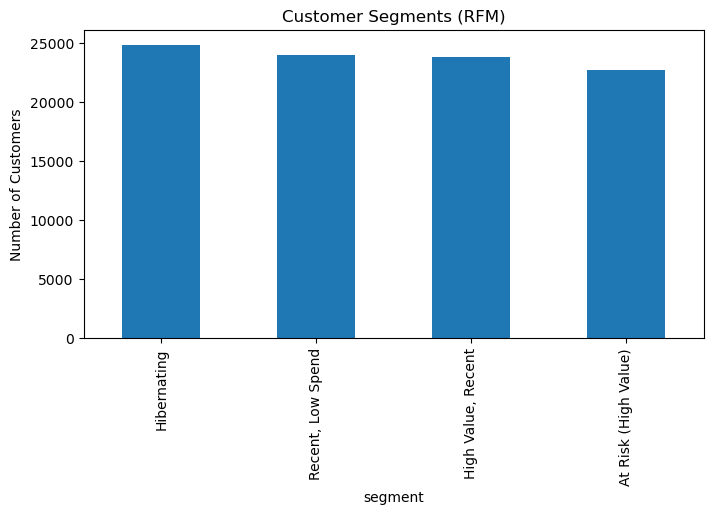

In [194]:
# Plotting R & M

segment_counts = rfm_df['segment'].value_counts()
segment_counts.plot(kind='bar', figsize=(8,4))
plt.title('Customer Segments (RFM)')
plt.ylabel('Number of Customers')
plt.show()

#### Note on unused columns ###

`f_score` and `rfm_score` are still present in `rfm_df` but are no longer used 
to determine `segment`, for the reason explained above (frequency scoring is 
unreliable for the ~75% of customers tied at a single order). They're kept in 
the dataframe for transparency/audit purposes — so the original scoring logic 
is still visible and traceable — but the actual customer segments are based 
only on `r_score` and `m_score`. The raw `frequency` column itself is still 
used separately to calculate the honest repeat-purchase rate (Step 9g).

#### K-Means Clustering ####

In [199]:
from sklearn.preprocessing import StandardScaler

rfm_for_clustering = rfm_df[['recency', 'monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_for_clustering)

print(rfm_scaled[:5])

[[-0.83312079 -0.05761497]
 [-0.81353336 -0.56759586]
 [ 1.94829305 -0.33741529]
 [ 0.53799871 -0.5350214 ]
 [ 0.32253708  0.1725656 ]]


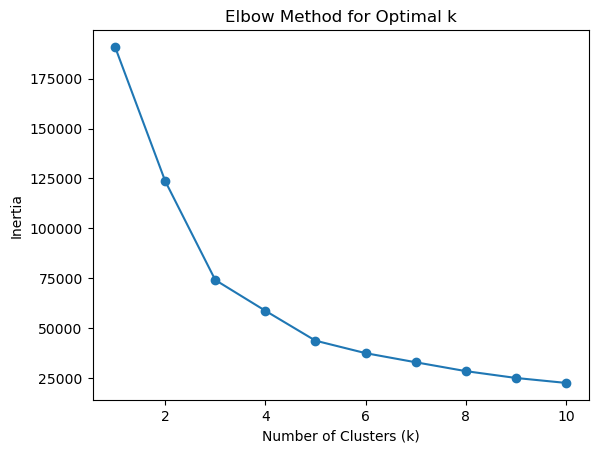

<Figure size 800x400 with 0 Axes>

In [205]:
# Obtaining Ebow Method

from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia_values.append(kmeans.inertia_)

plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.figure(figsize=(8,4))
plt.show()

In [207]:
# Running K-means with k=4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm_df['cluster'].value_counts())

cluster
0    52031
1    37695
2     5053
3      641
Name: count, dtype: int64


In [209]:
# Profiling the clusters

cluster_profile = rfm_df.groupby('cluster')[['recency', 'monetary']].mean()
print(cluster_profile)

            recency     monetary
cluster                         
0        133.026446   102.824678
1        395.051492   103.989660
2        233.153572   615.682329
3        246.237129  1888.673635


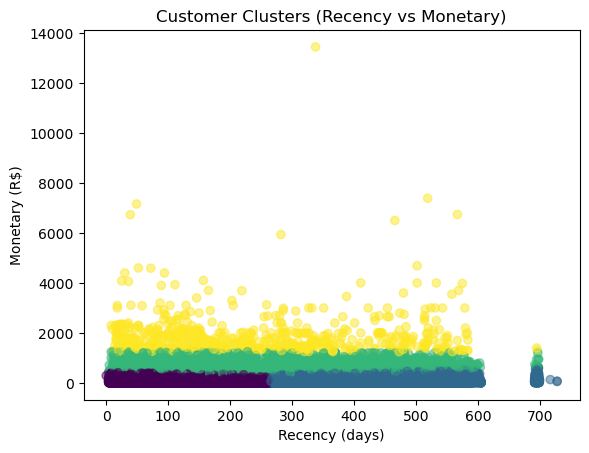

In [211]:
# Plotting the clusters

plt.scatter(rfm_df['recency'], rfm_df['monetary'], c=rfm_df['cluster'], cmap='viridis', alpha=0.5)
plt.title('Customer Clusters (Recency vs Monetary)')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (R$)')
plt.show()

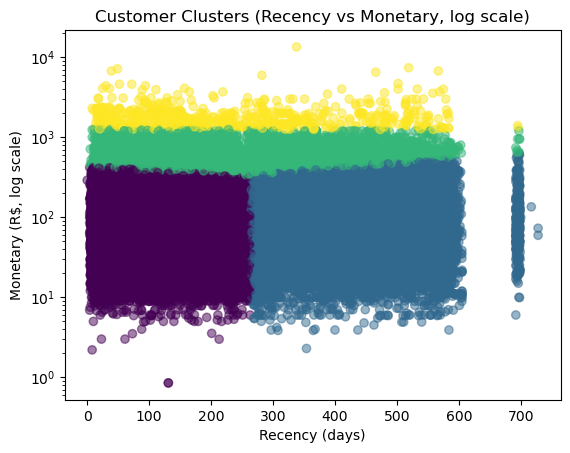

In [213]:
# Fxing the log scale on monetary

plt.scatter(rfm_df['recency'], rfm_df['monetary'], c=rfm_df['cluster'], cmap='viridis', alpha=0.5)
plt.yscale('log')
plt.title('Customer Clusters (Recency vs Monetary, log scale)')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (R$, log scale)')
plt.show()

In [229]:
# Exporting master_df

master_df.to_csv('data/master_df.csv', index=False)

In [231]:
import os
print(os.path.exists('data/master_df.csv'))

True


In [233]:
rfm_df.to_csv('data/rfm_df.csv', index=False)
print(os.path.exists('data/rfm_df.csv'))

True


In [235]:
rfm_df_export = rfm_df.reset_index()
rfm_df_export.to_csv('data/rfm_df.csv', index=False)
print(rfm_df_export.head())

                 customer_unique_id  recency  frequency  monetary r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      115          1    129.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      118          1     18.90       4   
2  0000f46a3911fa3c0805444483337064      541          1     69.00       1   
3  0000f6ccb0745a6a4b88665a16c9f078      325          1     25.99       2   
4  0004aac84e0df4da2b147fca70cf8255      292          1    180.00       2   

  f_score m_score rfm_score               segment  cluster  
0       1       3       413    High Value, Recent        0  
1       1       1       411     Recent, Low Spend        0  
2       1       2       112           Hibernating        1  
3       1       1       211           Hibernating        1  
4       1       4       214  At Risk (High Value)        1  
